# **Load some needed libraries**

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
from sklearn.model_selection import train_test_split ,GridSearchCV,RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier 
from sklearn.preprocessing import LabelEncoder, StandardScaler , RobustScaler
from scipy.stats import randint, uniform
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_recall_curve, precision_score, confusion_matrix

# **Load and explore DataSet**

In [2]:
df = pd.read_csv('crop_recommendation.csv')
df.head()

,nitrogen_mg_kg,phosphorus_mg_kg,potassium_mg_kg,soil_ph,organic_matter_pct,temperature_avg_c,humidity_pct,rainfall_mm,soil_type,region,season,recommended_crop
0,59.3,38.5,170.4,7.20,1.40,33.7,44.1,3.9,Clay,Delta,Summer,Cotton
1,92.0,34.2,211.4,7.20,1.90,34.0,51.7,3.2,Loamy,Upper_Egypt,Nile,Sugarcane
2,78.5,37.0,197.1,7.40,1.70,16.2,59.7,44.3,Sandy,Delta,Winter,Wheat
3,96.8,40.8,214.5,6.90,2.00,21.9,61.2,1.6,Loamy,North_Coast,Summer,Maize
4,21.4,36.2,112.4,6.59,1.47,14.5,76.1,50.4,Clay,North_Coast,Winter,Fava Beans


In [4]:
df.shape

(7000, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nitrogen_mg_kg      7000 non-null   float64
 1   phosphorus_mg_kg    7000 non-null   float64
 2   potassium_mg_kg     7000 non-null   float64
 3   soil_ph             7000 non-null   float64
 4   organic_matter_pct  7000 non-null   float64
 5   temperature_avg_c   7000 non-null   float64
 6   humidity_pct        7000 non-null   float64
 7   rainfall_mm         7000 non-null   float64
 8   soil_type           7000 non-null   object 
 9   region              7000 non-null   object 
 10  season              7000 non-null   object 
 11  recommended_crop    7000 non-null   object 
dtypes: float64(8), object(4)
memory usage: 656.4+ KB


In [6]:
print(f"num of nulls : \n {df.isna().sum()}")
print(f"num of duplicates : {df.duplicated().sum()}")

num of nulls : 
 nitrogen_mg_kg        0
phosphorus_mg_kg      0
potassium_mg_kg       0
soil_ph               0
organic_matter_pct    0
temperature_avg_c     0
humidity_pct          0
rainfall_mm           0
soil_type             0
region                0
season                0
recommended_crop      0
dtype: int64
num of duplicates : 0


C:\Users\ramez\AppData\Local\Temp\ipykernel_7152\680119831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variable', y='value', data=melted_df, palette='Set2')


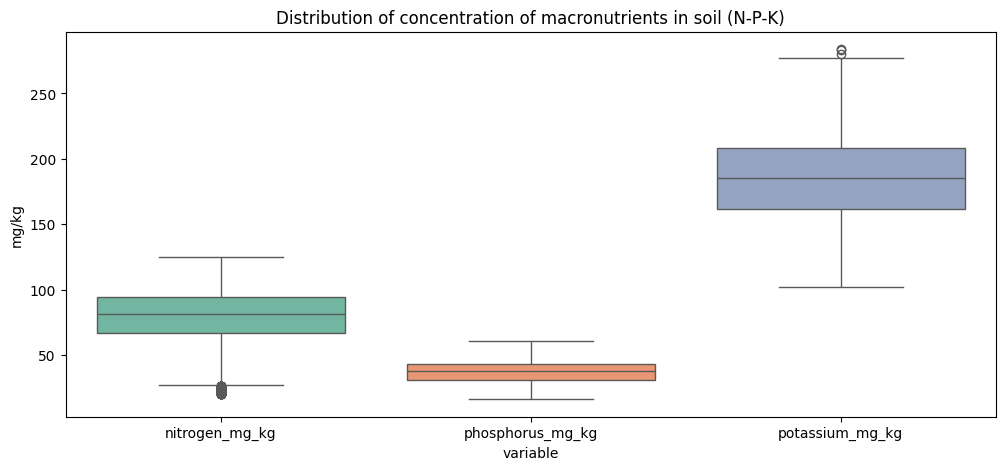

In [7]:
plt.figure(figsize=(12, 5))
melted_df = df.melt(value_vars=['nitrogen_mg_kg', 'phosphorus_mg_kg', 'potassium_mg_kg'])
sns.boxplot(x='variable', y='value', data=melted_df, palette='Set2')
plt.title('Distribution of concentration of macronutrients in soil (N-P-K)')
plt.ylabel('mg/kg')
plt.show()

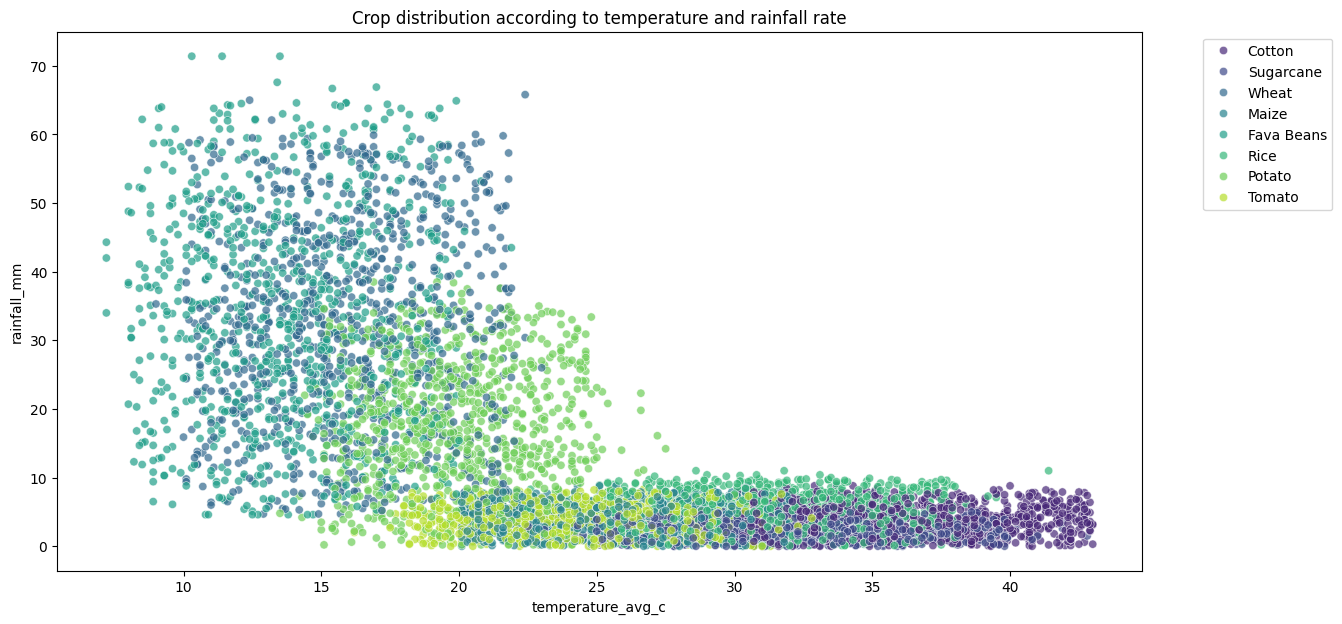

In [8]:
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df, x='temperature_avg_c', y='rainfall_mm', hue='recommended_crop', palette='viridis', alpha=0.7)
plt.title('Crop distribution according to temperature and rainfall rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

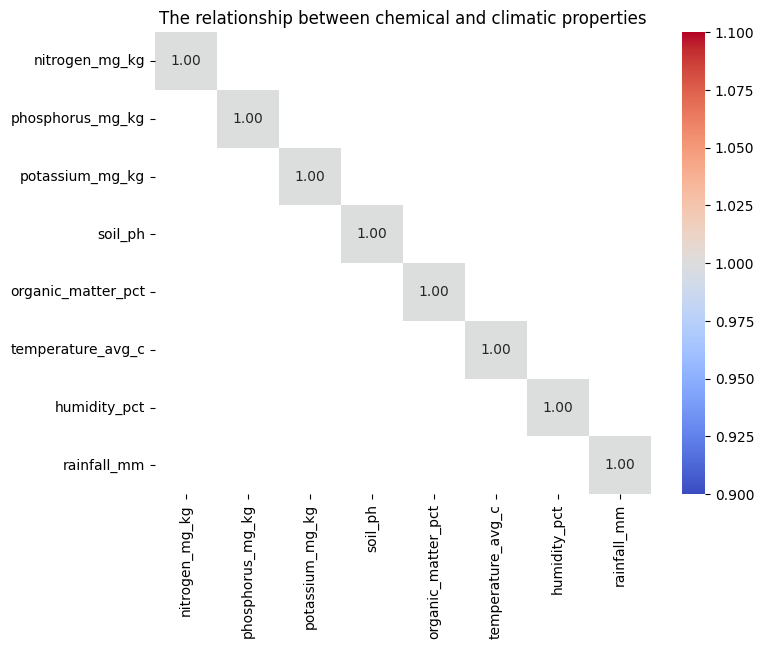

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f",mask=df.corr(numeric_only=True)<0.85)
plt.title('The relationship between chemical and climatic properties')
plt.show()

<Figure size 1200x1000 with 0 Axes>

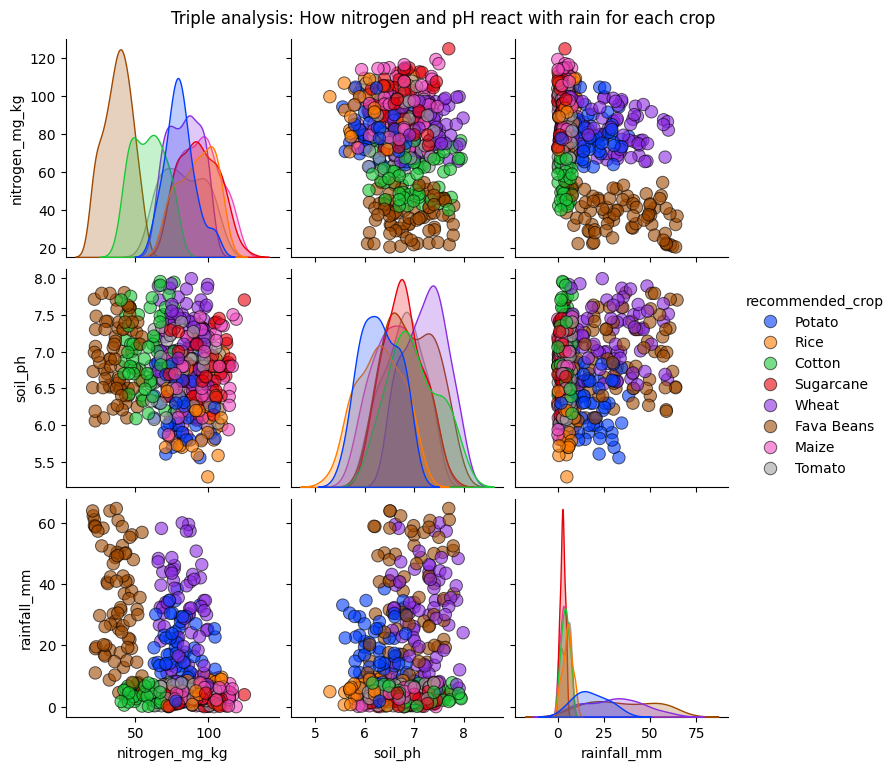

In [10]:
sample_df = df.sample(min(500, len(df)))

plt.figure(figsize=(12, 10))
sns.pairplot(sample_df, 
             vars=['nitrogen_mg_kg', 'soil_ph', 'rainfall_mm'], 
             hue='recommended_crop', 
             diag_kind='kde', 
             plot_kws={'alpha': 0.6, 's': 80, 'edgecolor': 'k'},
             palette='bright')
plt.suptitle('Triple analysis: How nitrogen and pH react with rain for each crop', y=1.02)
plt.show()

# **Feature Engineering**

In [ ]:
# # نسبة n/p و n/k بتفرق بين المحاصيل
# df['n_p_ratio'] = df['nitrogen_mg_kg'] / (df['phosphorus_mg_kg'] + 1)
# df['n_k_ratio'] = df['nitrogen_mg_kg'] / (df['potassium_mg_kg'] + 1)
# df['temp_humidity'] = df['temperature_avg_c'] * df['humidity_pct']
# df['heat_dryness'] = df['temperature_avg_c'] / (df['humidity_pct'] + 1)
# df['n_humidity_ratio'] = df['nitrogen_mg_kg'] / (df['humidity_pct'] + 1)
# df['water_stress'] = df['rainfall_mm'] * df['humidity_pct'] / 100
# df['npk_total'] = df['nitrogen_mg_kg'] + df['phosphorus_mg_kg'] + df['potassium_mg_kg']
# df['aridity_index'] = df['temperature_avg_c'] / (df['rainfall_mm'] + df['humidity_pct'] + 1)


In [11]:
df.head()

,nitrogen_mg_kg,phosphorus_mg_kg,potassium_mg_kg,soil_ph,organic_matter_pct,temperature_avg_c,humidity_pct,rainfall_mm,soil_type,region,season,recommended_crop
0,59.3,38.5,170.4,7.20,1.40,33.7,44.1,3.9,Clay,Delta,Summer,Cotton
1,92.0,34.2,211.4,7.20,1.90,34.0,51.7,3.2,Loamy,Upper_Egypt,Nile,Sugarcane
2,78.5,37.0,197.1,7.40,1.70,16.2,59.7,44.3,Sandy,Delta,Winter,Wheat
3,96.8,40.8,214.5,6.90,2.00,21.9,61.2,1.6,Loamy,North_Coast,Summer,Maize
4,21.4,36.2,112.4,6.59,1.47,14.5,76.1,50.4,Clay,North_Coast,Winter,Fava Beans


# **Detect Outliers**

In [12]:
num_col = df.select_dtypes(include=['int64','float64'])
cate_col = df.select_dtypes(include='object')

In [13]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    LB = Q1 - 1.5 * IQR
    UP = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < LB)  |  (df[col]  >  UP)].shape[0]
    
    print(f"--- {col} ---")
    print(f"{col} outlire : {outliers} , (LB: {LB:.2f}, UB: {UP:.2f})")
    print("-" * 30)

--- nitrogen_mg_kg ---
nitrogen_mg_kg outlire : 168 , (LB: 26.60, UB: 134.60)
------------------------------
--- phosphorus_mg_kg ---
phosphorus_mg_kg outlire : 0 , (LB: 12.40, UB: 62.00)
------------------------------
--- potassium_mg_kg ---
potassium_mg_kg outlire : 3 , (LB: 91.80, UB: 278.20)
------------------------------
--- soil_ph ---
soil_ph outlire : 0 , (LB: 5.10, UB: 8.30)
------------------------------
--- organic_matter_pct ---
organic_matter_pct outlire : 0 , (LB: 0.15, UB: 3.59)
------------------------------
--- temperature_avg_c ---
temperature_avg_c outlire : 0 , (LB: -1.15, UB: 51.25)
------------------------------
--- humidity_pct ---
humidity_pct outlire : 0 , (LB: 8.50, UB: 106.10)
------------------------------
--- rainfall_mm ---
rainfall_mm outlire : 497 , (LB: -21.30, UB: 43.50)
------------------------------


In [14]:
px.box(df['rainfall_mm'],
       color_discrete_sequence=['Green'],
       orientation="h",
       title="Rainfall Outlier")

In [15]:
num_col

,nitrogen_mg_kg,phosphorus_mg_kg,potassium_mg_kg,soil_ph,organic_matter_pct,temperature_avg_c,humidity_pct,rainfall_mm
0,59.3,38.5,170.4,7.20,1.400,33.7,44.1,3.9
1,92.0,34.2,211.4,7.20,1.900,34.0,51.7,3.2
2,78.5,37.0,197.1,7.40,1.700,16.2,59.7,44.3
3,96.8,40.8,214.5,6.90,2.000,21.9,61.2,1.6
4,21.4,36.2,112.4,6.59,1.470,14.5,76.1,50.4
...,...,...,...,...,...,...,...,...
6995,38.7,40.3,157.9,6.00,1.400,9.3,64.6,39.4
6996,61.0,27.7,142.7,6.33,2.289,26.1,50.1,4.7
6997,93.1,37.8,152.5,6.06,2.821,30.5,54.5,7.3
6998,94.7,37.7,179.3,6.00,2.200,31.7,75.8,4.3


In [16]:
df['recommended_crop'].unique()

array(['Cotton', 'Sugarcane', 'Wheat', 'Maize', 'Fava Beans', 'Rice',
       'Potato', 'Tomato'], dtype=object)

# **Encoding categorical features**

In [17]:
soil_map = {"Clay": 0, "Loamy": 1, "Calcareous": 2, "Sandy": 3}
region_map = {"Delta": 0, "Upper_Egypt": 1, "North_Coast": 2, "Sinai": 3, "NewLands": 4}
season_map = {"Winter": 0, "Summer": 1, "Nile": 2}
crop_map = {"Wheat": 0, "Maize": 1, "Cotton": 2, "Potato": 3, "Tomato": 4, "Sugarcane": 5, "Rice": 6, "Fava Beans": 7}

df['soil_type'] = df['soil_type'].map(soil_map)
df['region'] = df['region'].map(region_map)
df['season'] = df['season'].map(season_map)
df['recommended_crop'] = df['recommended_crop'].map(crop_map)

In [18]:
df.head()

,nitrogen_mg_kg,phosphorus_mg_kg,potassium_mg_kg,soil_ph,organic_matter_pct,temperature_avg_c,humidity_pct,rainfall_mm,soil_type,region,season,recommended_crop
0,59.3,38.5,170.4,7.20,1.40,33.7,44.1,3.9,0,0,1,2
1,92.0,34.2,211.4,7.20,1.90,34.0,51.7,3.2,1,1,2,5
2,78.5,37.0,197.1,7.40,1.70,16.2,59.7,44.3,3,0,0,0
3,96.8,40.8,214.5,6.90,2.00,21.9,61.2,1.6,1,2,1,1
4,21.4,36.2,112.4,6.59,1.47,14.5,76.1,50.4,0,2,0,7


# **Data Splitting**

In [19]:
df['recommended_crop'].value_counts()

recommended_crop
2    875
5    875
0    875
1    875
7    875
6    875
3    875
4    875
Name: count, dtype: int64

In [20]:
x = df.drop('recommended_crop', axis=1)
y = df['recommended_crop']

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5600, 11)
(1400, 11)
(5600,)
(1400,)


# **Model Training**

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_dist = {
    'n_estimators':    randint(200, 800),
    'max_depth':       randint(3, 9),
    'learning_rate':   uniform(0.01, 0.3),
    'subsample':       uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma':           uniform(0, 3),
    'reg_alpha':       uniform(0, 2),
    'reg_lambda':      uniform(1, 4),
}

random_xgb = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softprob',
        num_class=8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_weighted',
    cv=cv,
    verbose=1,
    random_state=42
)

random_xgb.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"XGBClassifier..._class=8, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....002A5378DF610>, 'gamma': <scipy.stats....002A506D60C30>, 'learning_rate': <scipy.stats....002A507050050>, 'max_depth': <scipy.stats....002A5378DEAD0>, ...}"
,n_iter,50
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


# **Model Evaluate**

In [24]:
best = random_xgb.best_estimator_
print("Best Params:", random_xgb.best_params_)
print("Train:", round(best.score(x_train, y_train), 4))
print("Test:",  round(best.score(x_test,  y_test),  4))

Best Params: {'colsample_bytree': np.float64(0.6353970008207678), 'gamma': np.float64(0.5879485872574356), 'learning_rate': np.float64(0.02356818667316142), 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 252, 'reg_alpha': np.float64(1.1735023313276964), 'reg_lambda': np.float64(4.861021229056552), 'subsample': np.float64(0.8428136990746738)}
Train: 0.9709
Test: 0.9521


In [25]:
y_pred = best.predict(x_test)
y_train_pred = best.predict(x_train)

In [27]:
print("Train Accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Test Accuracy:",  round(accuracy_score(y_test,  y_pred), 4))
print()

crop_names = ['Wheat', 'Maize', 'Cotton', 'Potato', 
              'Tomato', 'Sugarcane', 'Rice', 'Fava Beans']
print(classification_report(y_test, y_pred, target_names=crop_names))

Train Accuracy: 0.9709
Test Accuracy: 0.9521

              precision    recall  f1-score   support

       Wheat       0.98      0.99      0.99       157
       Maize       0.89      0.88      0.88       175
      Cotton       0.99      0.98      0.99       195
      Potato       0.98      0.95      0.96       188
      Tomato       0.92      0.86      0.89       176
   Sugarcane       0.96      0.98      0.97       178
        Rice       0.91      0.98      0.94       167
  Fava Beans       1.00      1.00      1.00       164

    accuracy                           0.95      1400
   macro avg       0.95      0.95      0.95      1400
weighted avg       0.95      0.95      0.95      1400



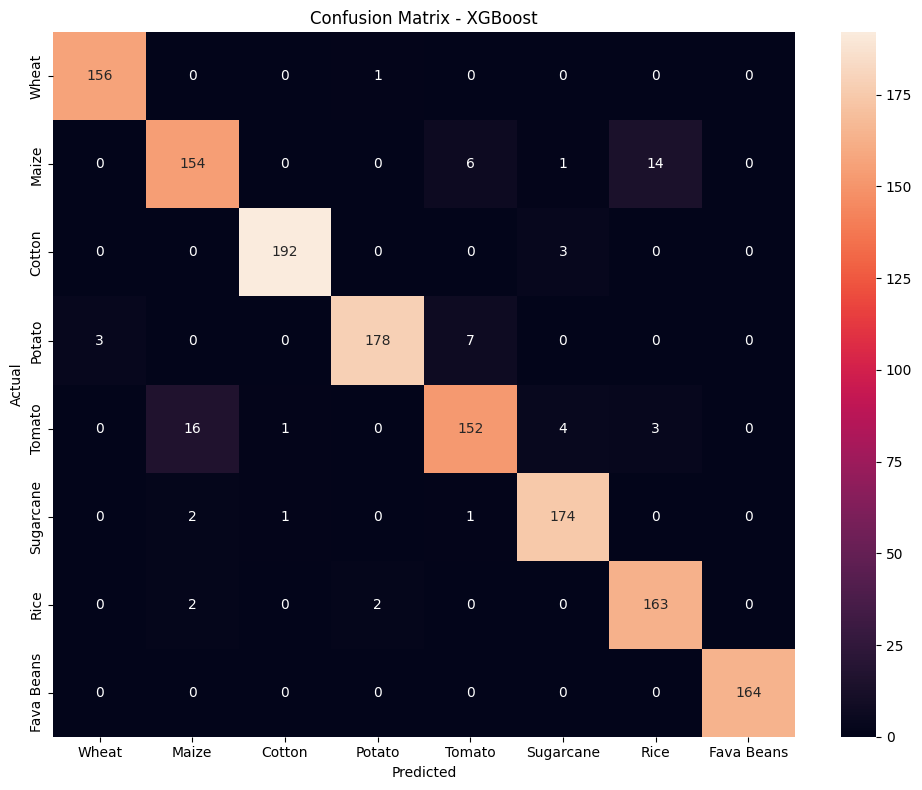

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=crop_names,
            yticklabels=crop_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.show()

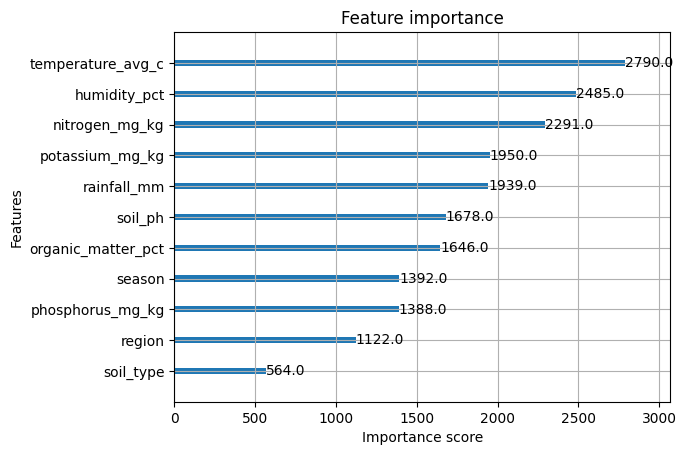

In [29]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(best)
plt.show()

# **Model Save**

In [30]:
import joblib

joblib.dump({
    'model': random_xgb.best_estimator_,
    'soil_map': soil_map,
    'region_map': region_map,
    'season_map': season_map,
    'crop_map': crop_map,
    'features': x.columns.tolist(),
}, 'crop_model.pkl')

print(" Saved!")

 Saved!
